# 01 - Distribuciones de Probabilidad

**Pregunta de negocio:** ¿Cómo se distribuyen nuestros datos?

## Objetivos
- Ajustar distribuciones teóricas a datos reales de telemetría
- Usar QQ-plots para evaluar normalidad visualmente
- Aplicar tests de bondad de ajuste (Shapiro-Wilk, Kolmogorov-Smirnov)
- Entender por qué importa la distribución para elegir tests estadísticos

## Teoría
- **Distribución Normal**: campana simétrica. Muchos tests asumen normalidad
- **QQ-plot**: si los datos siguen la distribución teórica, los puntos caen sobre la línea diagonal
- **Shapiro-Wilk**: test formal de normalidad. H₀: los datos son normales. Si p < 0.05, rechazamos normalidad
- **Kolmogorov-Smirnov**: compara la distribución empírica con una teórica
- **¿Por qué importa?** Si los datos no son normales, debemos usar tests no paramétricos (Mann-Whitney en vez de t-test)

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_dir = os.path.join(project_root, "data/raw")

In [2]:
# Cargar datos
files = sorted(glob.glob(os.path.join(data_dir, "telemetry/telemetry_*.csv")))
telemetry = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
fleet = pd.read_csv(os.path.join(data_dir, "fleet_profiles.csv"))
telemetry = telemetry.merge(fleet[['vehicle_id', 'vehicle_type']], on='vehicle_id', how='left')

print(f"Registros: {len(telemetry):,}")

Registros: 6,076,720


## 1. ¿Son normales nuestros datos? QQ-plots

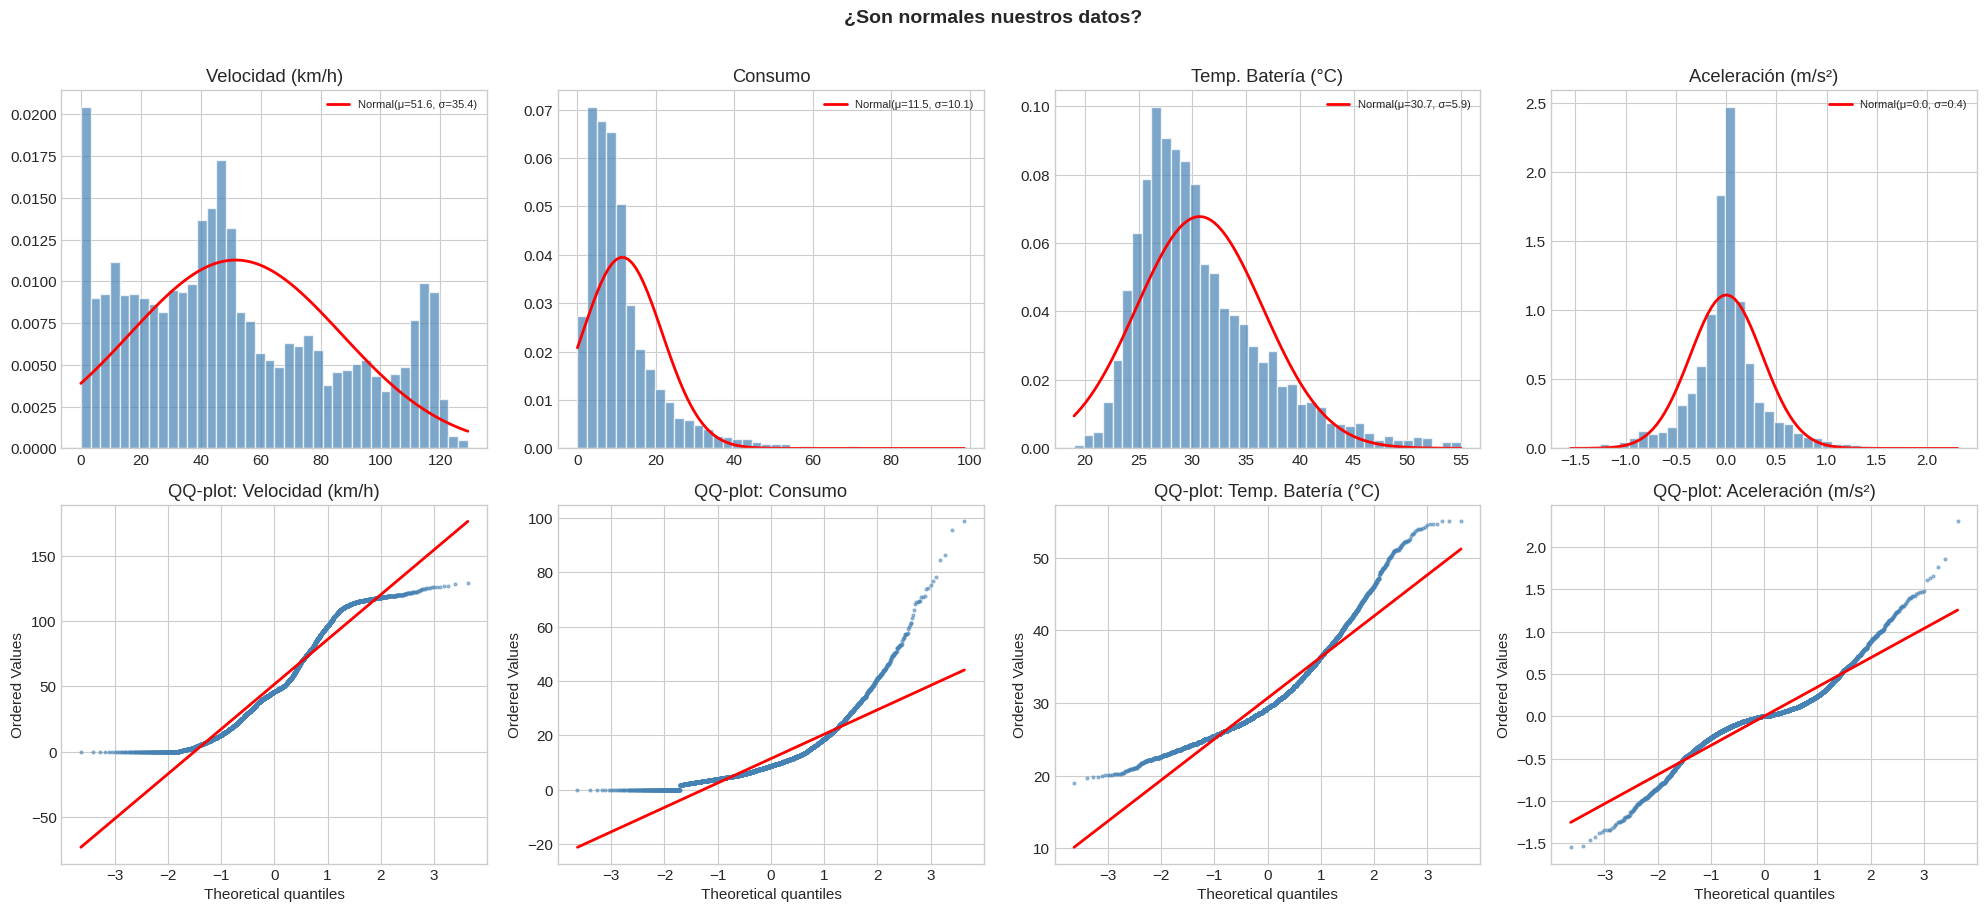

→ Si los puntos del QQ-plot se desvían de la línea roja, los datos NO son normales
→ Colas pesadas (puntos arriba/abajo) indican más valores extremos de lo esperado


In [3]:
variables = ['speed_kmh', 'fuel_consumption_rate', 'battery_temp_c', 'acceleration_ms2']
titles = ['Velocidad (km/h)', 'Consumo', 'Temp. Batería (°C)', 'Aceleración (m/s²)']

fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for i, (var, title) in enumerate(zip(variables, titles)):
    sample = telemetry[var].dropna().sample(5000, random_state=42)
    
    # Histograma + curva normal ajustada
    ax_hist = axes[0, i]
    ax_hist.hist(sample, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    mu, sigma = sample.mean(), sample.std()
    x = np.linspace(sample.min(), sample.max(), 100)
    ax_hist.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label=f'Normal(μ={mu:.1f}, σ={sigma:.1f})')
    ax_hist.set_title(title)
    ax_hist.legend(fontsize=8)
    
    # QQ-plot
    ax_qq = axes[1, i]
    stats.probplot(sample, dist='norm', plot=ax_qq)
    ax_qq.set_title(f'QQ-plot: {title}')
    ax_qq.get_lines()[0].set(color='steelblue', markersize=2, alpha=0.5)
    ax_qq.get_lines()[1].set(color='red', linewidth=2)

plt.suptitle('¿Son normales nuestros datos?', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("→ Si los puntos del QQ-plot se desvían de la línea roja, los datos NO son normales")
print("→ Colas pesadas (puntos arriba/abajo) indican más valores extremos de lo esperado")

## 2. Tests formales de normalidad

In [4]:
# Shapiro-Wilk (máximo 5000 muestras) y Kolmogorov-Smirnov
results = []
for var, title in zip(variables, titles):
    sample = telemetry[var].dropna().sample(5000, random_state=42)
    
    # Shapiro-Wilk
    stat_sw, p_sw = stats.shapiro(sample)
    
    # Kolmogorov-Smirnov (comparar con normal)
    stat_ks, p_ks = stats.kstest(sample, 'norm', args=(sample.mean(), sample.std()))
    
    # Skewness y Kurtosis
    skew = sample.skew()
    kurt = sample.kurtosis()
    
    results.append({
        'Variable': title,
        'Shapiro p-value': p_sw,
        'K-S p-value': p_ks,
        'Skewness': skew,
        'Kurtosis': kurt,
        '¿Normal?': '✓' if p_sw > 0.05 else '✗',
    })

results_df = pd.DataFrame(results)
print("Tests de Normalidad (α = 0.05):")
print("Si p-value < 0.05 → rechazamos normalidad")
print()
results_df

Tests de Normalidad (α = 0.05):
Si p-value < 0.05 → rechazamos normalidad



,Variable,Shapiro p-value,K-S p-value,Skewness,Kurtosis,¿Normal?
0,Velocidad (km/h),4.805523e-40,5.858074e-34,0.413884,-0.903257,✗
1,Consumo,8.132465e-63,3.077577e-113,2.442157,9.203868,✗
2,Temp. Batería (°C),5.889730e-46,3.849867e-50,1.195714,1.579942,✗
3,Aceleración (m/s²),1.282411e-44,2.757041e-63,0.243551,3.391131,✗


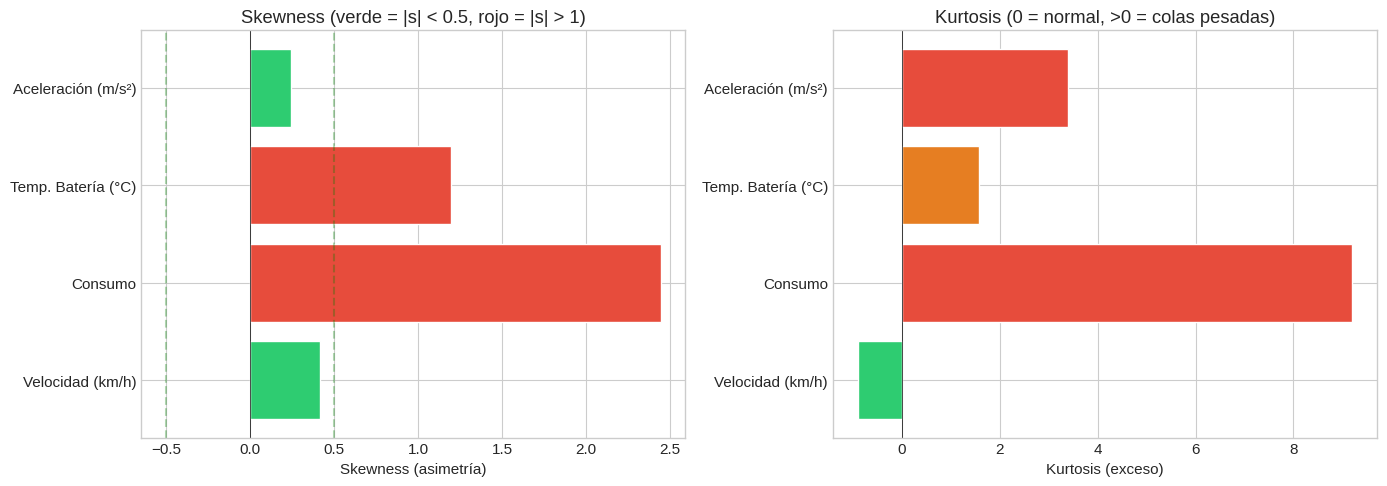

→ Skewness: 0 = simétrica, >0 = cola derecha, <0 = cola izquierda
→ Kurtosis: 0 = normal, >0 = más outliers de lo esperado


In [5]:
# Visualizar skewness y kurtosis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_bar = ['#2ecc71' if abs(s) < 0.5 else '#e67e22' if abs(s) < 1 else '#e74c3c' 
              for s in results_df['Skewness']]
axes[0].barh(results_df['Variable'], results_df['Skewness'], color=colors_bar, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.5)
axes[0].axvline(-0.5, color='green', linestyle='--', alpha=0.3)
axes[0].axvline(0.5, color='green', linestyle='--', alpha=0.3)
axes[0].set_xlabel('Skewness (asimetría)')
axes[0].set_title('Skewness (verde = |s| < 0.5, rojo = |s| > 1)')

colors_k = ['#2ecc71' if abs(k) < 1 else '#e67e22' if abs(k) < 3 else '#e74c3c' 
             for k in results_df['Kurtosis']]
axes[1].barh(results_df['Variable'], results_df['Kurtosis'], color=colors_k, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Kurtosis (exceso)')
axes[1].set_title('Kurtosis (0 = normal, >0 = colas pesadas)')

plt.tight_layout()
plt.show()

print("→ Skewness: 0 = simétrica, >0 = cola derecha, <0 = cola izquierda")
print("→ Kurtosis: 0 = normal, >0 = más outliers de lo esperado")

## 3. Ajustar distribuciones alternativas

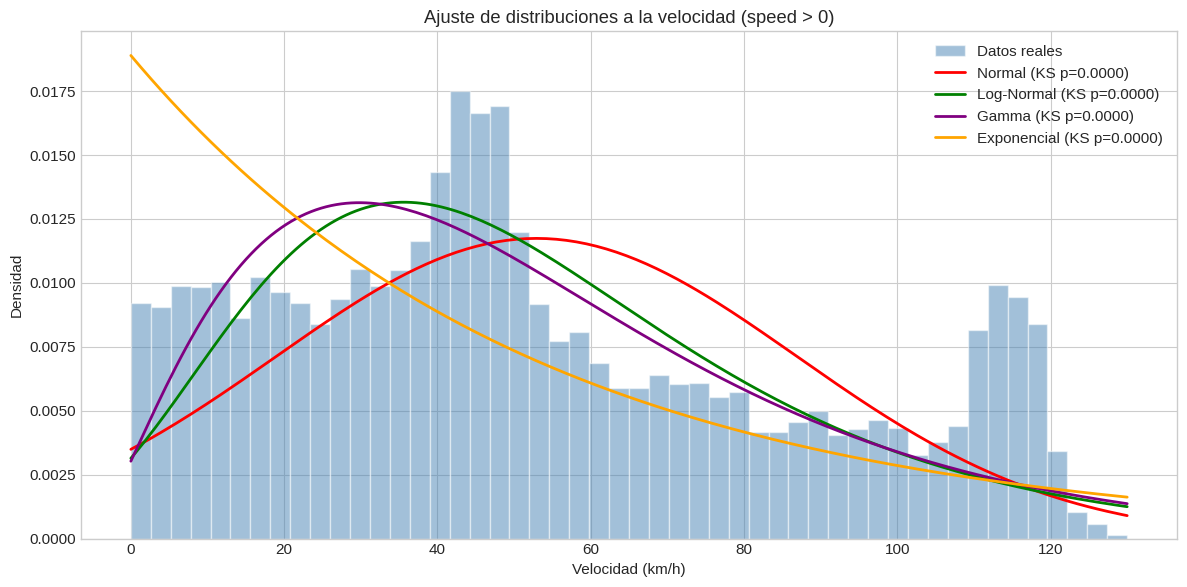


Bondad de ajuste (mayor p-value = mejor ajuste):


,Distribución,KS statistic,KS p-value
1,Log-Normal,0.047980,1.912160e-20
2,Gamma,0.048448,7.749937e-21
0,Normal,0.094193,1.144781e-77
3,Exponencial,0.151309,2.393748e-200


In [6]:
# Intentar ajustar varias distribuciones a la velocidad
speed_sample = telemetry['speed_kmh'].dropna()
speed_sample = speed_sample[speed_sample > 0].sample(10000, random_state=42)

distributions = {
    'Normal': stats.norm,
    'Log-Normal': stats.lognorm,
    'Gamma': stats.gamma,
    'Exponencial': stats.expon,
}

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(speed_sample, bins=50, density=True, alpha=0.5, color='steelblue', edgecolor='white', label='Datos reales')

x = np.linspace(speed_sample.min(), speed_sample.max(), 200)
fit_results = []
dist_colors = ['red', 'green', 'purple', 'orange']

for (name, dist), color in zip(distributions.items(), dist_colors):
    try:
        params = dist.fit(speed_sample)
        pdf = dist.pdf(x, *params)
        ks_stat, ks_p = stats.kstest(speed_sample, dist.cdf, args=params)
        ax.plot(x, pdf, color=color, linewidth=2, label=f'{name} (KS p={ks_p:.4f})')
        fit_results.append({'Distribución': name, 'KS statistic': ks_stat, 'KS p-value': ks_p})
    except Exception as e:
        fit_results.append({'Distribución': name, 'KS statistic': np.nan, 'KS p-value': np.nan})

ax.set_xlabel('Velocidad (km/h)')
ax.set_ylabel('Densidad')
ax.set_title('Ajuste de distribuciones a la velocidad (speed > 0)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nBondad de ajuste (mayor p-value = mejor ajuste):")
pd.DataFrame(fit_results).sort_values('KS p-value', ascending=False)

## 4. Normalidad por tipo de vehículo

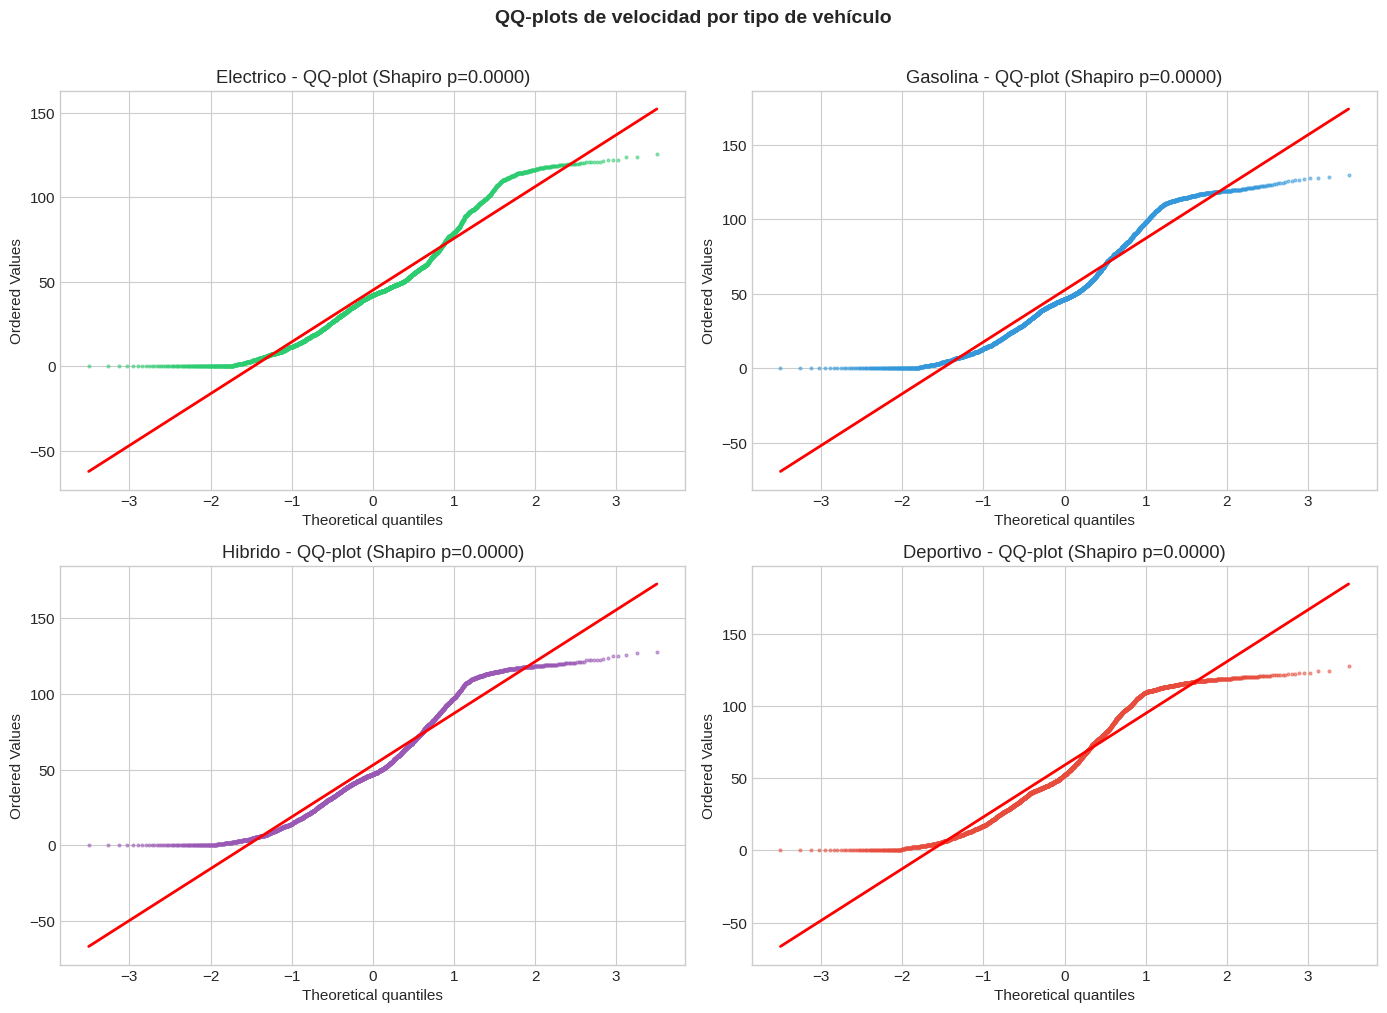

→ Si p < 0.05 en Shapiro, la velocidad NO es normal para ese tipo
→ Esto determina qué test usar en los siguientes notebooks


In [7]:
# ¿La velocidad es normal dentro de cada tipo?
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
vtype_colors = {'electrico': '#2ecc71', 'gasolina': '#3498db', 'hibrido': '#9b59b6', 'deportivo': '#e74c3c'}

for ax, vtype in zip(axes.flat, ['electrico', 'gasolina', 'hibrido', 'deportivo']):
    sample = telemetry[telemetry['vehicle_type'] == vtype]['speed_kmh'].dropna().sample(
        min(3000, len(telemetry[telemetry['vehicle_type'] == vtype])), random_state=42)
    
    stats.probplot(sample, dist='norm', plot=ax)
    ax.get_lines()[0].set(color=vtype_colors[vtype], markersize=2, alpha=0.5)
    ax.get_lines()[1].set(color='red', linewidth=2)
    
    _, p = stats.shapiro(sample[:5000])
    ax.set_title(f'{vtype.capitalize()} - QQ-plot (Shapiro p={p:.4f})')

plt.suptitle('QQ-plots de velocidad por tipo de vehículo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("→ Si p < 0.05 en Shapiro, la velocidad NO es normal para ese tipo")
print("→ Esto determina qué test usar en los siguientes notebooks")

## 5. Teorema del Límite Central (CLT)

Aunque los datos individuales no sean normales, las **medias de muestras** sí tienden a serlo.
Esto es fundamental porque muchos tests trabajan con medias.

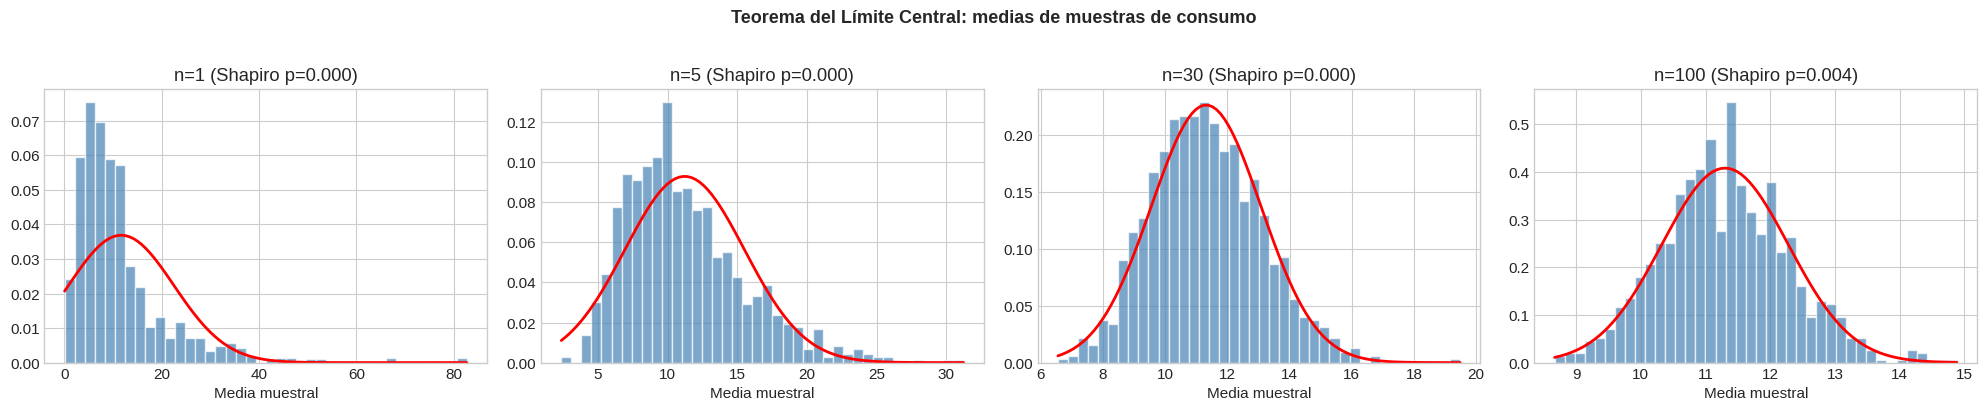

→ Con n=1: la distribución original (no normal)
→ Con n=30+: las medias ya son prácticamente normales
→ Por eso n=30 se considera el umbral mínimo para usar tests paramétricos


In [8]:
# Demostrar CLT: tomar muchas muestras y calcular sus medias
consumption = telemetry['fuel_consumption_rate'].dropna().values

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
sample_sizes = [1, 5, 30, 100]
n_samples = 1000
rng = np.random.default_rng(42)

for ax, n in zip(axes, sample_sizes):
    means = [rng.choice(consumption, size=n).mean() for _ in range(n_samples)]
    ax.hist(means, bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='white')
    
    # Ajustar normal
    mu, sigma = np.mean(means), np.std(means)
    x = np.linspace(min(means), max(means), 100)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2)
    
    _, p = stats.shapiro(means)
    ax.set_title(f'n={n} (Shapiro p={p:.3f})')
    ax.set_xlabel('Media muestral')

plt.suptitle('Teorema del Límite Central: medias de muestras de consumo', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("→ Con n=1: la distribución original (no normal)")
print("→ Con n=30+: las medias ya son prácticamente normales")
print("→ Por eso n=30 se considera el umbral mínimo para usar tests paramétricos")

## Resumen

### Lo que aprendimos:
1. **QQ-plot**: herramienta visual rápida para evaluar normalidad
2. **Shapiro-Wilk / K-S**: tests formales (p < 0.05 → no es normal)
3. **Skewness/Kurtosis**: métricas numéricas de la forma de la distribución
4. **CLT**: con muestras grandes (n≥30), las medias son normales aunque los datos no lo sean
5. La distribución determina qué test usar: paramétrico (normal) vs no paramétrico

### Respuesta:
> **¿Cómo se distribuyen nuestros datos?**
>
> La mayoría de las variables de telemetría NO son normales: velocidad tiene sesgo
> positivo (muchos valores bajos + cola de valores altos), consumo es asimétrico.
> Sin embargo, gracias al CLT y al gran volumen de datos, podemos usar tests
> paramétricos para comparar medias. Para distribuciones muy sesgadas, preferimos
> tests no paramétricos.

### Siguiente:
→ `02_confidence_intervals.ipynb`: Intervalos de confianza